1. Load dataset & Keep final test set

In [2]:
import pandas as pd

from sklearn.model_selection import train_test_split


# =========================
# 1. Load dataset
# =========================

df = pd.read_json("../donnees/articles.json")

X = df["body"]
y = df["categories"].str[0]


# =========================
# 2. Keep final test set
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


2. Development Data

In [3]:
print("=== DEVELOPMENT DATA ===")

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nNumber of samples:", len(X_train))

print("\nCategory distribution:")
print(y_train.value_counts())

=== DEVELOPMENT DATA ===
X_train shape: (16800,)
y_train shape: (16800,)

Number of samples: 16800

Category distribution:
categories
ثقافة     2800
دولي      2800
اقتصاد    2800
رياضة     2800
سياسة     2800
مجتمع     2800
Name: count, dtype: int64


3. Preprocessing

In [4]:
import unicodedata


def normalize_arabic(text):
    return (
        text.replace("أ", "ا")
            .replace("إ", "ا")
            .replace("آ", "ا")
    )


def remove_diacritics(text):
    return "".join(
        char
        for char in text
        if unicodedata.category(char) != "Mn"
        
    )


def remove_tatweel(text):
    return text.replace("ـ", "")

def remove_taarif(text):
    return " ".join(
        word.removeprefix("ال")
        for word in text.split()
    )

def remove_numbers(text):
    return "".join(
        char
        for char in text
        if not char.isdigit()
    )

def remove_marks(text):
    return text.replace('\\"', '"').replace('"', '') if isinstance(text, str) else text

arabic_stopwords = {
    "في", "من", "إلى", "على", "عن", "و", "أو",
    "أن", "إن", "كان", "كانت", "هذا", "هذه",
    "ذلك", "التي", "الذي", "هو", "هي", "هم",
    "ما", "لا", "لم", "لن", "مع", "كما"
}

def remove_stopwords(text):
    return " ".join(
        word
        for word in text.split()
        if word not in arabic_stopwords
    )

def preprocess(text):
    text = normalize_arabic(text)
    text = remove_diacritics(text)
    text = remove_tatweel(text)
    text = remove_taarif(text)
    text = remove_numbers(text)
    text = remove_marks(text)
    text = remove_stopwords(text)

    return text
X_train = X_train.apply(preprocess)
X_test = X_test.apply(preprocess)

4. 5-fold cross-validation

In [5]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("Number of folds:", skf.get_n_splits())

Number of folds: 5


5. Verify the folds

In [6]:
for fold, (train_index, val_index) in enumerate(
    skf.split(X_train, y_train),
    start=1
):
    print(f"\n========== FOLD {fold} ==========")

    print("Training size:", len(train_index))
    print("Validation size:", len(val_index))

    print("\nValidation distribution:")
    print(
        y_train.iloc[val_index]
        .value_counts()
        .sort_index()
    )


========== FOLD 1 ==========
Training size: 13440
Validation size: 3360

Validation distribution:
categories
اقتصاد    560
ثقافة     560
دولي      560
رياضة     560
سياسة     560
مجتمع     560
Name: count, dtype: int64

========== FOLD 2 ==========
Training size: 13440
Validation size: 3360

Validation distribution:
categories
اقتصاد    560
ثقافة     560
دولي      560
رياضة     560
سياسة     560
مجتمع     560
Name: count, dtype: int64

========== FOLD 3 ==========
Training size: 13440
Validation size: 3360

Validation distribution:
categories
اقتصاد    560
ثقافة     560
دولي      560
رياضة     560
سياسة     560
مجتمع     560
Name: count, dtype: int64

========== FOLD 4 ==========
Training size: 13440
Validation size: 3360

Validation distribution:
categories
اقتصاد    560
ثقافة     560
دولي      560
رياضة     560
سياسة     560
مجتمع     560
Name: count, dtype: int64

========== FOLD 5 ==========
Training size: 13440
Validation size: 3360

Validation distribution:
categories
اقتصاد    

6. TF-IDF & Logistic Regression & Macro F1

In [7]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

def run_cv(ngram_range=(1, 1), min_df=2, C=1.0):

    fold_scores = []

    for fold, (train_index, val_index) in enumerate(
        skf.split(X_train, y_train),
        start=1
    ):

        X_fold_train = X_train.iloc[train_index]
        X_fold_val = X_train.iloc[val_index]

        y_fold_train = y_train.iloc[train_index]
        y_fold_val = y_train.iloc[val_index]

        # TF-IDF
        vectorizer = TfidfVectorizer(
            min_df=min_df,
            ngram_range=ngram_range
        )

        X_fold_train_tfidf = vectorizer.fit_transform(
            X_fold_train
        )

        X_fold_val_tfidf = vectorizer.transform(
            X_fold_val
        )

        # Logistic Regression
        lr_model = LogisticRegression(
            C=C,
            max_iter=10000
        )

        lr_model.fit(
            X_fold_train_tfidf,
            y_fold_train
        )

        # Prediction
        y_fold_pred = lr_model.predict(
            X_fold_val_tfidf
        )

        # Macro F1
        fold_f1 = f1_score(
            y_fold_val,
            y_fold_pred,
            average="macro"
        )

        fold_scores.append(fold_f1)

    return np.mean(fold_scores), np.std(fold_scores)

7. Mean/Std

In [8]:
baseline_mean, baseline_std = run_cv(
    ngram_range=(1, 1),
    min_df=2,
    C=1.0
)

print("Unigrams")
print("Mean Macro F1:", baseline_mean)
print("Std:", baseline_std)

Unigrams
Mean Macro F1: 0.8844296818814342
Std: 0.004727562190965272


8. Final evaluation on the held-out test set

Cross-validation above is used to estimate performance and select settings. Here, we fit one final TF-IDF + Logistic Regression model using all development/training data, then evaluate it once on the held-out test set. Keep this test set separate from model selection.


In [9]:
# Train the final TF-IDF vectorizer on the complete training split.
final_vectorizer = TfidfVectorizer(
    min_df=2,
    ngram_range=(1, 1)
)
X_train_tfidf = final_vectorizer.fit_transform(X_train)
X_test_tfidf = final_vectorizer.transform(X_test)

# Fit the final Logistic Regression classifier on all training examples.
final_model = LogisticRegression(
    C=1.0,
    max_iter=10000
)
final_model.fit(X_train_tfidf, y_train)

# Predict categories for the held-out test examples.
y_pred = final_model.predict(X_test_tfidf)

print("Test predictions:", len(y_pred))


Test predictions: 4200


9. Classification report

The report gives precision, recall, and F1-score for each category. The macro average gives each category equal weight, while weighted average accounts for the number of examples in each category.


              precision    recall  f1-score   support

      اقتصاد       0.86      0.86      0.86       700
       ثقافة       0.93      0.93      0.93       700
        دولي       0.87      0.94      0.90       700
       رياضة       0.99      0.99      0.99       700
       سياسة       0.86      0.84      0.85       700
       مجتمع       0.87      0.82      0.84       700

    accuracy                           0.90      4200
   macro avg       0.90      0.90      0.90      4200
weighted avg       0.90      0.90      0.90      4200



,precision,recall,f1-score
اقتصاد,0.859,0.861,0.860
ثقافة,0.934,0.934,0.934
دولي,0.867,0.941,0.903
رياضة,0.990,0.987,0.989
سياسة,0.861,0.841,0.851
مجتمع,0.872,0.817,0.844


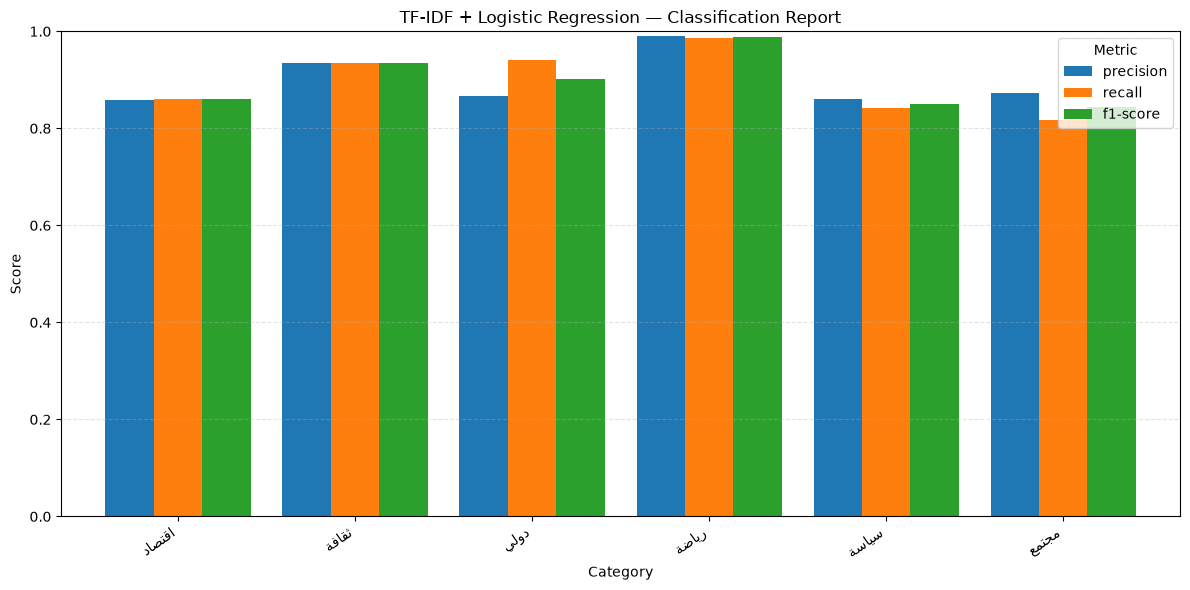

In [10]:
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt

# Print the standard text report.
print(classification_report(y_test, y_pred, zero_division=0))

# Convert the report to a DataFrame for plotting.
report_dict = classification_report(
    y_test,
    y_pred,
    output_dict=True,
    zero_division=0
)
report_df = pd.DataFrame(report_dict).T

# Keep only category rows (exclude accuracy and summary rows).
class_names = list(final_model.classes_)
class_report = report_df.loc[class_names, ["precision", "recall", "f1-score"]]

display(class_report.round(3))

# Plot precision, recall, and F1-score side by side for each category.
ax = class_report.plot(
    kind="bar",
    figsize=(12, 6),
    ylim=(0, 1),
    width=0.82
)
ax.set_title("TF-IDF + Logistic Regression — Classification Report")
ax.set_xlabel("Category")
ax.set_ylabel("Score")
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right")
ax.grid(axis="y", linestyle="--", alpha=0.35)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()


10. Confusion matrix

Rows show the true categories and columns show the predicted categories. The diagonal contains correct predictions; off-diagonal cells show which categories are confused with one another.


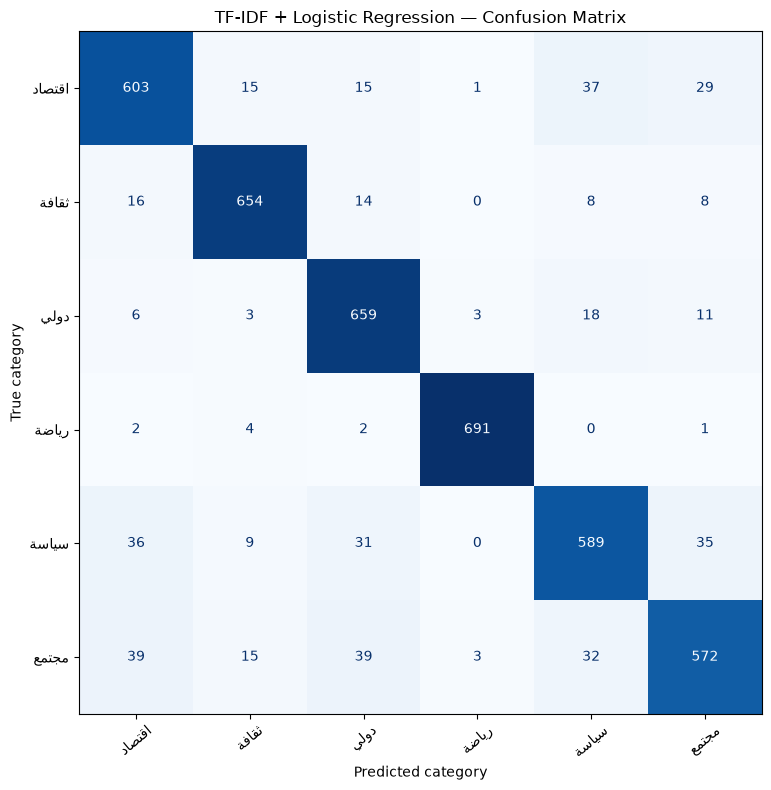

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Use the classifier's class order so the labels match the matrix axes.
cm = confusion_matrix(y_test, y_pred, labels=class_names)

fig, ax = plt.subplots(figsize=(9, 8))
display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)
display.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    xticks_rotation=40,
    colorbar=False
)
ax.set_title("TF-IDF + Logistic Regression — Confusion Matrix")
ax.set_xlabel("Predicted category")
ax.set_ylabel("True category")
plt.tight_layout()
plt.show()


11. Optional: normalized confusion matrix

This version normalizes each true-category row to show the proportion of examples assigned to each predicted category. It can make per-category error patterns easier to compare when category counts differ.


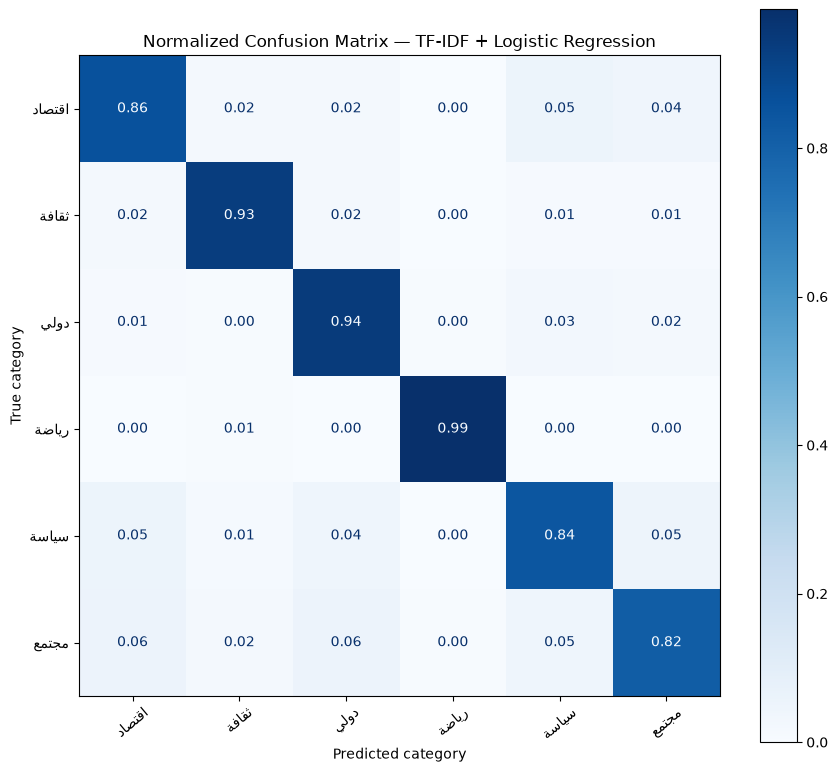

In [12]:
cm_normalized = confusion_matrix(
    y_test,
    y_pred,
    labels=class_names,
    normalize="true"
)

fig, ax = plt.subplots(figsize=(9, 8))
display = ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized,
    display_labels=class_names
)
display.plot(
    ax=ax,
    cmap="Blues",
    values_format=".2f",
    xticks_rotation=40,
    colorbar=True
)
ax.set_title("Normalized Confusion Matrix — TF-IDF + Logistic Regression")
ax.set_xlabel("Predicted category")
ax.set_ylabel("True category")
plt.tight_layout()
plt.show()


In [16]:
import joblib

joblib.dump(final_model, "tfidf_classifier.joblib")

['tfidf_classifier.joblib']

In [14]:
from huggingface_hub import login

login()

In [18]:
from huggingface_hub import HfApi

api = HfApi()

api.upload_file(
    path_or_fileobj="tfidf_classifier.joblib",
    path_in_repo="tfidf_classifier.joblib",
    repo_id="salah-2005/baseline_tfidf",
    repo_type="model"
)

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/salah-2005/baseline_tfidf/commit/07248b1add10bcf07eb95bbd76c31b552e6ff08e', commit_message='Upload tfidf_classifier.joblib with huggingface_hub', commit_description='', oid='07248b1add10bcf07eb95bbd76c31b552e6ff08e', pr_url=None, repo_url=RepoUrl('https://huggingface.co/salah-2005/baseline_tfidf', endpoint='https://huggingface.co', repo_type='model', repo_id='salah-2005/baseline_tfidf'), pr_revision=None, pr_num=None)

In [19]:
import joblib
from huggingface_hub import hf_hub_download
from sentence_transformers import SentenceTransformer

repo_id = "salah-2005/baseline_tfidf"

classifier_path = hf_hub_download(
    repo_id=repo_id,
    filename="tfidf_classifier.joblib"
)

classifier = joblib.load(classifier_path)


tfidf_classifier.joblib: reconstructing file:   0%|          |  0.00B / 3.58MB            

tfidf_classifier.joblib: downloading bytes:           |  0.00B            